# EVALUATION & VALIDATION

+ Kiểm tra Overfiting
+ So sánh các mô hình sau khi tinh chỉnh
+ Trả lời các câu hỏi nghiên cứu

## 1. Khởi tạo và đọc dữ liệu
Đầu tiên, chúng ta tải các thư viện cần thiết và nhập các mô hình đã tinh chỉnh.

### 1.1 Thư viện và dữ liệu

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Thư viện đánh giá, phân chia dữ liệu, chuẩn hóa
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (confusion_matrix, roc_curve, auc,classification_report,
                            accuracy_score, precision_score, recall_score, f1_score )    

# Các mô hình ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Đọc dữ liệu từ Feature Engineering (Đã Scale & Encode)
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"THÔNG TIN DỮ LIỆU")
print(f"Shape Train: {X_train.shape}")
print(f"Shape Test:  {X_test.shape}")
print(f"Tỷ lệ nghỉ việc (Train): {np.mean(y_train):.2%}") 
# Lưu ý: Với tỷ lệ ~43%, dữ liệu khá cân bằng, không cần kỹ thuật xử lý mất cân bằng quá gắt.

# Kiểm tra nhanh tên cột (để phát hiện lỗi khoảng trắng)
print("\nDanh sách đặc trưng:")
print(X_train.columns.tolist())

THÔNG TIN DỮ LIỆU
Shape Train: (952, 20)
Shape Test:  (239, 20)
Tỷ lệ nghỉ việc (Train): 43.28%

Danh sách đặc trưng:
['Age', 'Academic_degree', 'Years_Experience', 'MonthlySalary', 'Allowances', 'Get_ Deserved_Promotion', 'Training_programs_ During_last_three_years', 'Job_Support', 'Emotional_Commitment', 'Job_Engagement', 'Distance_to_work', 'Work_Live_Balance', 'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability', 'Environment_Satisfaction', 'Job_Satisfaction', 'Job_Opportunities', 'JobTitle_Freq', 'Stability_Ratio']


### 1.2 Mô hình sau khi tối ưu

In [3]:
# 1. Mô hình Random Forest
RF = joblib.load('tuned_random_forest.pkl')

print("Đã load mô hình thành công!")
print(RF)
best_params_RF = RF.get_params()

print("Các tham số tối ưu trước đó:")
print(f"  - Max Depth: {best_params_RF.get('max_depth')}")
print(f"  - N Estimators: {best_params_RF.get('n_estimators')}")
print(f"  - Min Samples Leaf: {best_params_RF.get('min_samples_leaf')}")
print(f"  - Class Weight: {best_params_RF.get('class_weight')}")

Đã load mô hình thành công!
RandomForestClassifier(max_depth=8, max_features=0.5, min_samples_leaf=5,
                       random_state=42)
Các tham số tối ưu trước đó:
  - Max Depth: 8
  - N Estimators: 100
  - Min Samples Leaf: 5
  - Class Weight: None


In [4]:
# 2. Mô hình SVM
SVM = joblib.load('tuned_svm.pkl')

print("Đã load mô hình thành công!")
print(SVM)
best_params_SVM = SVM.get_params()

print("Các tham số tối ưu trước đó:")
print(f"  - C: {best_params_SVM.get('C')}")
print(f"  - Gamma: {best_params_SVM.get('gamma')}")
print(f"  - kernel: {best_params_SVM.get('kernel')}")


Đã load mô hình thành công!
SVC(C=1, probability=True, random_state=42)
Các tham số tối ưu trước đó:
  - C: 1
  - Gamma: scale
  - kernel: rbf


In [5]:
# 3. Mô hình Ensemble
ensemble = joblib.load('best_ensemble_model.pkl')

print("Đã load mô hình thành công!")
print(ensemble)
best_params = ensemble.get_params()

Đã load mô hình thành công!
VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=8,
                                                     max_features=0.5,
                                                     min_samples_leaf=5,
                                                     random_state=42)),
                             ('svm',
                              SVC(C=1, probability=True, random_state=42)),
                             ('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42))],
                 voting='soft')


## 2. Overfiting

Tiếp theo, kiếm tra Overfiting nhằm đánh giá mô hình có đáng tin cậy khi đánh giá hay không.

### 2.1 Support Vector Machine

In [6]:
# Dự đoán
y_train_pred_SVM = SVM.predict(X_train)
y_test_pred_SVM  = SVM.predict(X_test)

# Tính F1 & Accuracy
train_f1_SVM = f1_score(y_train, y_train_pred_SVM)
test_f1_SVM  = f1_score(y_test, y_test_pred_SVM)

train_acc_SVM = accuracy_score(y_train, y_train_pred_SVM)
test_acc_SVM  = accuracy_score(y_test, y_test_pred_SVM)

print("=== SVM: TRAIN vs TEST ===")
print(f"Train F1: {train_f1_SVM:.4f} | Train Acc: {train_acc_SVM:.4f}")
print(f"Test  F1: {test_f1_SVM:.4f} | Test  Acc: {test_acc_SVM:.4f}")

diff = train_f1_SVM - test_f1_SVM
print(f"F1 Difference (Train - Test): {diff:.4f}")


=== SVM: TRAIN vs TEST ===
Train F1: 0.8271 | Train Acc: 0.8582
Test  F1: 0.7320 | Test  Acc: 0.7824
F1 Difference (Train - Test): 0.0952


In [7]:
cv_scores_svm = cross_val_score(
    SVM,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("\n=== CROSS-VALIDATION (TRAIN SET) ===")
print("CV F1 scores:", cv_scores_svm)
print(f"CV Mean: {cv_scores_svm.mean():.4f}")
print(f"CV Std : {cv_scores_svm.std():.4f}")


=== CROSS-VALIDATION (TRAIN SET) ===
CV F1 scores: [0.81012658 0.72483221 0.75496689 0.73417722 0.79503106]
CV Mean: 0.7638
CV Std : 0.0335


### 2.2 Random Forest

In [8]:
# Dự đoán
y_train_pred_RF = RF.predict(X_train)
y_test_pred_RF  = RF.predict(X_test)

# Tính F1 & Accuracy
train_f1_RF = f1_score(y_train, y_train_pred_RF)
test_f1_RF  = f1_score(y_test, y_test_pred_RF)

train_acc = accuracy_score(y_train, y_train_pred_RF)
test_acc  = accuracy_score(y_test, y_test_pred_RF)

print("=== RF: TRAIN vs TEST ===")
print(f"Train F1: {train_f1_RF:.4f} | Train Acc: {train_acc:.4f}")
print(f"Test  F1: {test_f1_RF:.4f} | Test  Acc: {test_acc:.4f}")

diff = train_f1_RF - test_f1_RF
print(f"F1 Difference (Train - Test): {diff:.4f}")


=== RF: TRAIN vs TEST ===
Train F1: 0.8696 | Train Acc: 0.8929
Test  F1: 0.7817 | Test  Acc: 0.8201
F1 Difference (Train - Test): 0.0878


In [9]:
cv_scores_rf = cross_val_score(
    RF,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("\n=== CROSS-VALIDATION (TRAIN SET) ===")
print("CV F1 scores:", cv_scores_rf)
print(f"CV Mean: {cv_scores_rf.mean():.4f}")
print(f"CV Std : {cv_scores_rf.std():.4f}")


=== CROSS-VALIDATION (TRAIN SET) ===
CV F1 scores: [0.79487179 0.76623377 0.77333333 0.75       0.82894737]
CV Mean: 0.7827
CV Std : 0.0273


### 2.3. Ensemble

In [10]:
# Dự đoán
y_train_pred_ensemble = ensemble.predict(X_train)
y_test_pred_ensemble  = ensemble.predict(X_test)

# Tính F1 & Accuracy
train_f1_ensemble = f1_score(y_train, y_train_pred_ensemble)
test_f1_ensemble  = f1_score(y_test, y_test_pred_ensemble)

train_acc_ensemble = accuracy_score(y_train, y_train_pred_ensemble)
test_acc_ensemble  = accuracy_score(y_test, y_test_pred_ensemble)

print("=== Ensemble: TRAIN vs TEST ===")
print(f"Train F1: {train_f1_ensemble:.4f} | Train Acc: {train_acc_ensemble:.4f}")
print(f"Test  F1: {test_f1_ensemble:.4f} | Test  Acc: {test_acc_ensemble:.4f}")
diff = train_f1_ensemble - test_f1_ensemble
print(f"F1 Difference (Train - Test): {diff:.4f}")


=== Ensemble: TRAIN vs TEST ===
Train F1: 0.8291 | Train Acc: 0.8592
Test  F1: 0.7739 | Test  Acc: 0.8117
F1 Difference (Train - Test): 0.0552


In [11]:
cv_scores_en = cross_val_score(
    ensemble,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("\n=== CROSS-VALIDATION (TRAIN SET) ===")
print("CV F1 scores:", cv_scores_en)
print(f"CV Mean: {cv_scores_en.mean():.4f}")
print(f"CV Std : {cv_scores_en.std():.4f}")


=== CROSS-VALIDATION (TRAIN SET) ===
CV F1 scores: [0.8        0.73825503 0.76       0.73417722 0.7875    ]
CV Mean: 0.7640
CV Std : 0.0261


### 2.4. Nhận xét

Cả 3 mô hình có độ ổn định (CV Std < 0.04) và không bị overfiting (F1 Difference < 0.1).

Kết luận: Mô hình đã được kiểm soát tốt nhất có thể. Có thể đánh giá dữ liệu dựa trên các mô hình này.

## 3. Đánh giá mô hình

Mô hình được đánh giá dựa trên 3 tiêu chí: 
+ AUC-ROC
+ Classification Report 
+ Confusion Matrix

In [12]:
# Lấy các model + ensemble
models = {
    "Random Forest": RF,
    "SVM": SVM,
    "Logistic Regression": ensemble.named_estimators_["lr"],
    "Ensemble (Soft Voting)": ensemble
}

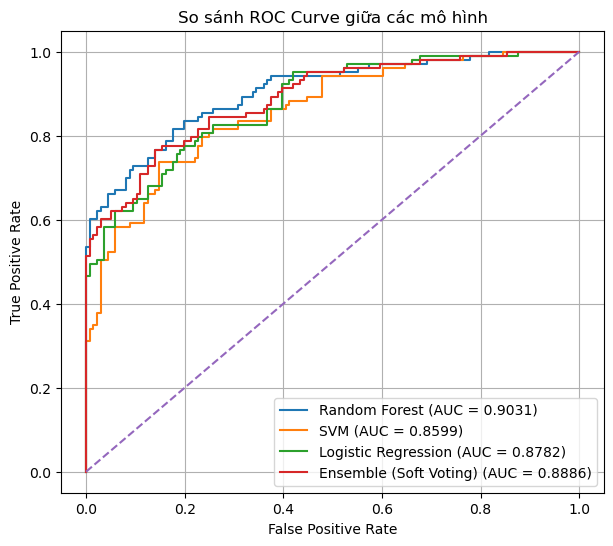

In [13]:
plt.figure(figsize=(7, 6))

for name, model in models.items():
    # Lấy xác suất lớp dương
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

# Đường baseline
plt.plot([0, 1], [0, 1], linestyle="--",)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh ROC Curve giữa các mô hình")
plt.legend()
plt.grid(True)
plt.show()


**Nhận xét:** Mô hình Random Forest là mô hình tối ưu nhất (AUC = 0.9031), vượt qua mô hình Ensemble.

**Lí do mô hình Random Forest vượt qua cả mô hình Ensemble:** do sự pha trộn kết quả của các mô hình con, nên việc AUC của SVM thấp đã vô tình kéo lùi hiệu suất trung bình xuống, khiến Ensemble hoạt động kém hơn so với Random Forest đứng độc lập.



MODEL: Random Forest

Accuracy = 0.8201

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       136
           1       0.82      0.75      0.78       103

    accuracy                           0.82       239
   macro avg       0.82      0.81      0.81       239
weighted avg       0.82      0.82      0.82       239



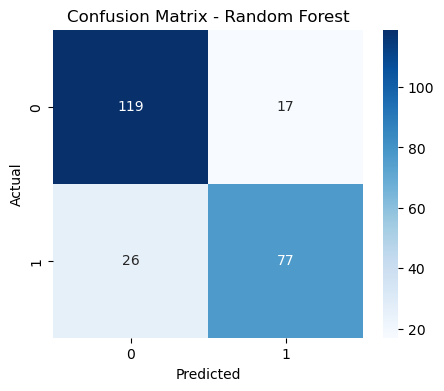


MODEL: SVM

Accuracy = 0.7824

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       136
           1       0.78      0.69      0.73       103

    accuracy                           0.78       239
   macro avg       0.78      0.77      0.77       239
weighted avg       0.78      0.78      0.78       239



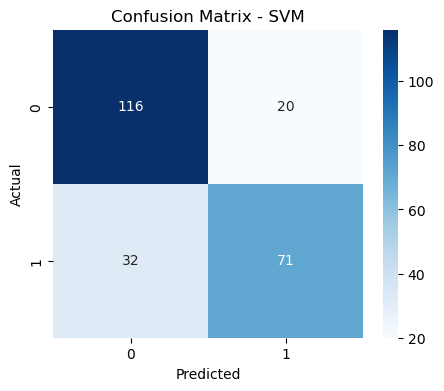


MODEL: Logistic Regression

Accuracy = 0.7782

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       136
           1       0.78      0.68      0.73       103

    accuracy                           0.78       239
   macro avg       0.78      0.77      0.77       239
weighted avg       0.78      0.78      0.78       239



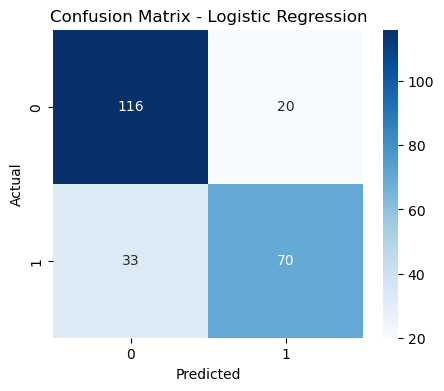


MODEL: Ensemble (Soft Voting)

Accuracy = 0.8117

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       136
           1       0.80      0.75      0.77       103

    accuracy                           0.81       239
   macro avg       0.81      0.80      0.81       239
weighted avg       0.81      0.81      0.81       239



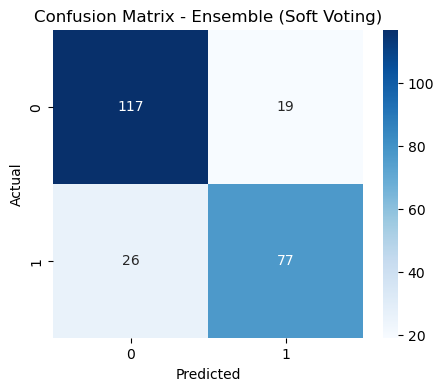

In [14]:
for name, model in models.items():
    print("\n" + "="*50)
    print(f"MODEL: {name}")
    print("="*50)

    # Dự đoán nhãn
    y_pred = model.predict(X_test)

    # --------- Classification Report ---------
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy = {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # --------- Confusion Matrix ---------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()



**Nhận xét:** 
+ Nhìn chung, mô hình **SVM** và **Logistic Regression** có kết quả thấp hơn so với **Random Forest** và **Ensemble**.
+ Dù 2 mô hình cho ra kết quả không chênh lệch quá nhiều, tuy nhiên do bộ dữ liệu không quá lớn nên cần độ chính xác cao nhất.

**Kết luận:** Mô hình Random Forest vẫn hoạt động tốt nhất.

**Random Forest:** 
+ Vì bài toán đặt ra là "Đưa ra các quyết định giữ chân nhân tài kịp thời và chính xác hơn" nên ta sẽ chú trọng vào giá trị Recall nhằm tránh khả năng bỏ sót nhân viên nghỉ việc.
+ Mô hình Random Forest đạt Accuracy = 82%, cho thấy hiệu quả phân loại khá tốt. Precision hai lớp cân bằng (0.82), nhưng recall lớp 1 thấp hơn (0.75), chứng tỏ mô hình còn bỏ sót một số mẫu lớp 1.


## 4. Feature importance

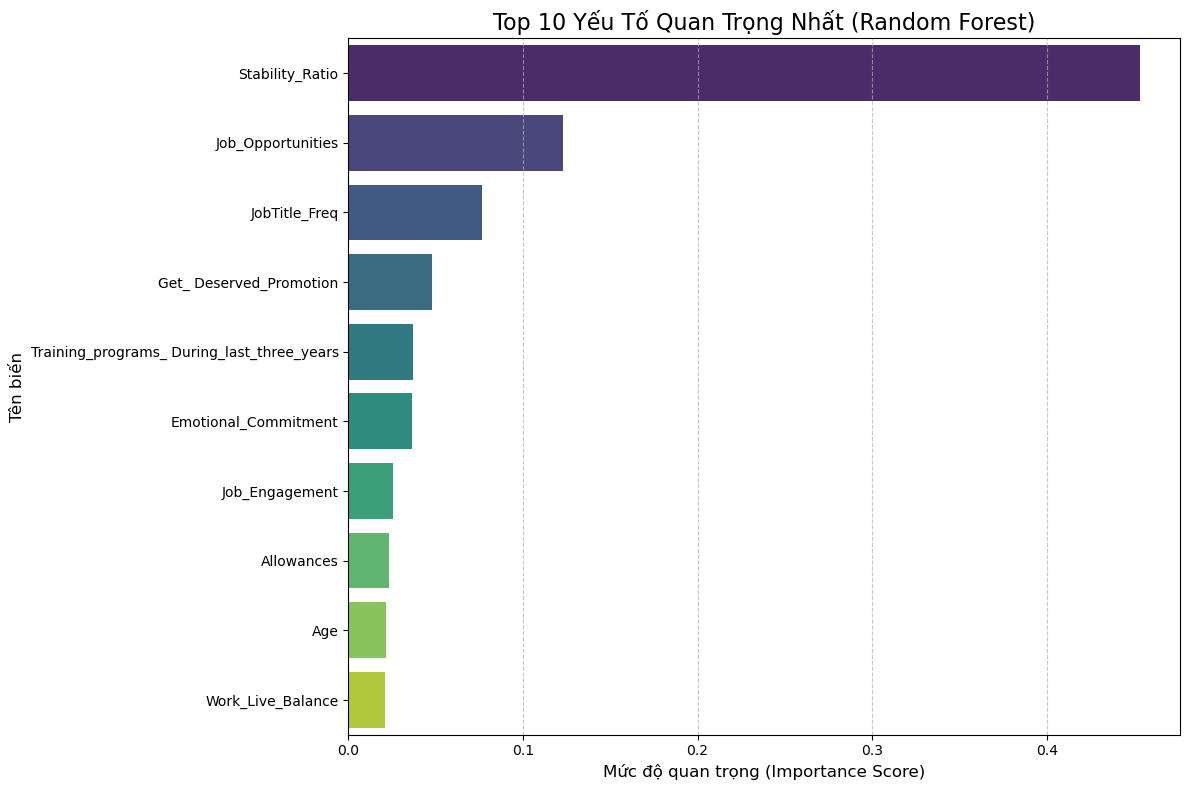

In [15]:
# Lấy importance từ mô hình Random Forest đã huấn luyện
importances = RF.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sắp xếp giảm dần và lấy 10 biến quan trọng nhất
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')

# Trang trí biểu đồ
plt.title('Top 10 Yếu Tố Quan Trọng Nhất (Random Forest)', fontsize=16)
plt.xlabel('Mức độ quan trọng (Importance Score)', fontsize=12)
plt.ylabel('Tên biến', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Hiển thị
plt.tight_layout()
plt.show()

**Nhận xét:** Biến **Stability_Ratio** có mức độ quan trọng vượt trội, cho thấy đây là yếu tố ảnh hưởng mạnh nhất đến dự đoán của mô hình Random Forest. Một nhân viên có tỉ lệ ổn định lâu dài với công việc hay không là dấu hiệu báo trước mạnh mẽ nhất cho việc có nghỉ việc hay không.

Các yếu tố như **Job_Opportunities (cơ hội bên ngoài)** và **JobTitle_Freq (chức danh)** cũng đóng vai trò đáng kể, trong khi **Age (tuổi)** và **Work_Live_Balance (cân bằng cuộc sống)** có ảnh hưởng thấp hơn.


## 5. Kết luận

Kết quả từ mô hình **Random Forest (AUC 0.90)** khẳng định **Stability_Ratio (tỉ lệ ổn định)** và **Job_Opportunities (cơ hội bên ngoài)** là hai yếu tố then chốt quyết định việc nghỉ việc, lấn át các yếu tố về phúc lợi ngắn hạn. Doanh nghiệp cần định kỳ thực hiện khảo sát lương, phúc lợi (Salary Benchmarking) cũng như thăng cấp các nhân viên tiềm năng để đảm bảo đãi ngộ của công ty không thấp hơn mặt bằng chung, làm giảm sức hấp dẫn của các lời mời gọi bên ngoài. Đồng thời, nên ứng dụng mô hình này để sàng lọc ứng viên dựa trên độ ổn định quá khứ và cảnh báo sớm rủi ro nhân sự tiềm ẩn.

Tuy nhiên do Recall lớp 1 (nghỉ việc) của mô hình Random Forest thấp hơn so với lớp 0 (ở lại) nhưng không quá đáng kể, có thể cân nhắc đến việc tối ưu bằng cách giảm ngưỡng tối ưu (threshold) hay loại bỏ các đặc trưng (feature) không quan trọng để cho ra kết quả tối ưu hơn.